In [2]:
#!pip install tbats statsmodels
import json
import pandas as pd
import numpy as np
from datetime import timedelta

# Install missing package
!pip install tbats

# If statsmodels is also missing:
!pip install statsmodels

from tbats import TBATS
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 27.8 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
with open('/content/drive/MyDrive/Child Guardian GP 1/data exploration/synthetic_usage_final.json', 'r') as f:
    data = json.load(f)

# Normalize the nested structure
df = pd.json_normalize(
    data,
    record_path='apps',  # Path to the nested array
    meta=['date', 'weekday', 'is_weekend', 'total_time_min', 'app_count']  # Metadata to include
)

print(df.head())
print(f"\nShape: {df.shape}")

                    package  time_ms  time_min      last_used     app_name  \
0    com.synthetic.linkedin   205156         3  1704068711000     linkedin   
1      com.synthetic.notion     8620         0  1704071543000       notion   
2     com.synthetic.twitter  4212949        70  1704099119000      twitter   
3  com.synthetic.googlemaps    21007         0  1704100117000  google maps   
4     com.synthetic.weather     8783         0  1704100743000      weather   

       category        date weekday is_weekend total_time_min app_count  
0        Social  2024-01-01       0      False             75        10  
1  Productivity  2024-01-01       0      False             75        10  
2        Social  2024-01-01       0      False             75        10  
3     Utilities  2024-01-01       0      False             75        10  
4     Utilities  2024-01-01       0      False             75        10  

Shape: (6776, 11)


In [5]:
df['date'] = pd.to_datetime(df['date'])

# -----------------------------
# Aggregate daily usage per app
# -----------------------------
daily_usage = df.groupby(['date', 'app_name'])['time_min'].sum().unstack(fill_value=0)
daily_usage = daily_usage.asfreq('D', fill_value=0)

print(daily_usage.head())

# -----------------------------
# Choose apps for TBATS and ETS
# -----------------------------
# daily_usage is your df: rows = dates, cols = apps
tbats_apps = []
ets_apps = []

for app in daily_usage.columns:
    series = daily_usage[app]
    zero_days_ratio = (series == 0).sum() / len(series)  # sparsity
    coef_var = series.std() / (series.mean() + 1e-6)    # variation

    # Decision rules
    if zero_days_ratio < 0.5 and coef_var > 0.3:  # lots of non-zero days + some variation → TBATS
        tbats_apps.append(app)
    else:
        ets_apps.append(app)

print("TBATS apps:", tbats_apps)
print("ETS apps:", ets_apps)

app_name    2048  8 ball pool  afk arena  among us  angry birds  \
date                                                              
2024-01-01     0            0          0         0            0   
2024-01-02     0            0          0         0            0   
2024-01-03     0            0          0         0            0   
2024-01-04     0            0          0         0            0   
2024-01-05     0            0          0         0            0   

app_name    angry birds 2  angry birds dream blast  asphalt 9: legends  \
date                                                                     
2024-01-01              0                        0                   0   
2024-01-02              0                        0                   0   
2024-01-03              0                        0                   0   
2024-01-04              0                        0                   0   
2024-01-05              0                        0                   0   

app_name   

In [6]:
# -----------------------------
# Function to fit TBATS and forecast
# -----------------------------
def tbats_forecast(series, steps=7):
    estimator = TBATS(
        seasonal_periods=[7],  # weekly seasonality
        use_arma_errors=True,
        use_trend=True,
        use_damped_trend=True
    )
    model = estimator.fit(series.values)
    forecast = model.forecast(steps=steps)
    residuals = series.values - model.y_hat
    return forecast, residuals, model

# -----------------------------
# Function to fit ETS and forecast
# -----------------------------
def ets_forecast(series, steps=7):
    model = ExponentialSmoothing(
        series.values,
        trend='add',
        seasonal='add',
        seasonal_periods=7
    ).fit()
    forecast = model.forecast(steps)
    residuals = series.values - model.fittedvalues
    return forecast, residuals, model

# -----------------------------
# Store results
# -----------------------------
forecasts = {}
residuals_dict = {}

# TBATS apps
for app in tbats_apps:
    if app in daily_usage.columns:
        series = daily_usage[app]
        fc, res, model = tbats_forecast(series)
        forecasts[app] = fc
        residuals_dict[app] = res

# ETS apps
for app in ets_apps:
    if app in daily_usage.columns:
        series = daily_usage[app]
        fc, res, model = ets_forecast(series)
        forecasts[app] = fc
        residuals_dict[app] = res

# -----------------------------
# Detect anomalies (simple method)
# -----------------------------
def detect_anomalies(residuals, threshold_std=2):
    mean = np.mean(residuals)
    std = np.std(residuals)
    anomalies = np.abs(residuals - mean) > threshold_std * std
    return anomalies

anomaly_flags = {}
for app, res in residuals_dict.items():
    anomaly_flags[app] = detect_anomalies(res)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

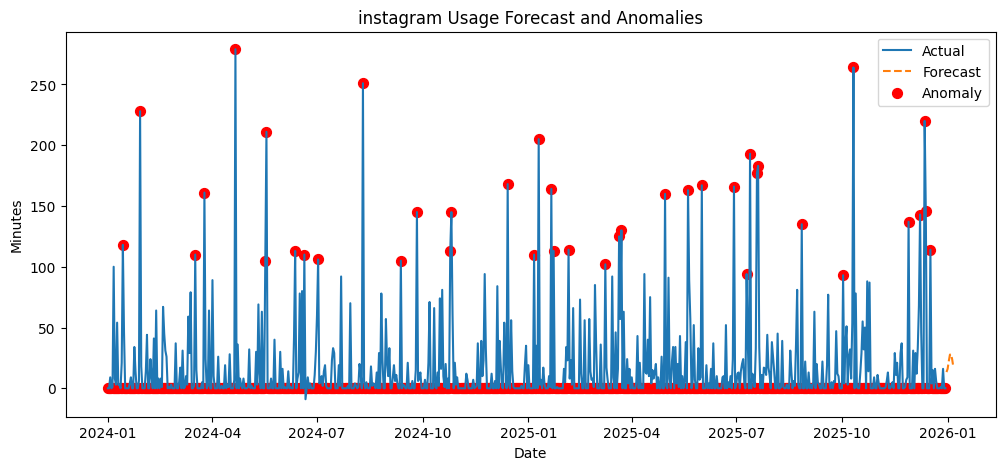

In [7]:
# -----------------------------
# Plot results for one app
# -----------------------------
app_to_plot = 'instagram'
if app_to_plot in daily_usage.columns:
    plt.figure(figsize=(12,5))
    series = daily_usage[app_to_plot]
    plt.plot(series.index, series.values, label='Actual')
    future_dates = pd.date_range(series.index[-1] + timedelta(days=1), periods=7)
    plt.plot(future_dates, forecasts[app_to_plot], label='Forecast', linestyle='--')
    plt.scatter(series.index, series.values * anomaly_flags[app_to_plot], color='red', label='Anomaly', s=50)
    plt.title(f"{app_to_plot} Usage Forecast and Anomalies")
    plt.xlabel("Date")
    plt.ylabel("Minutes")
    plt.legend()
    plt.show()

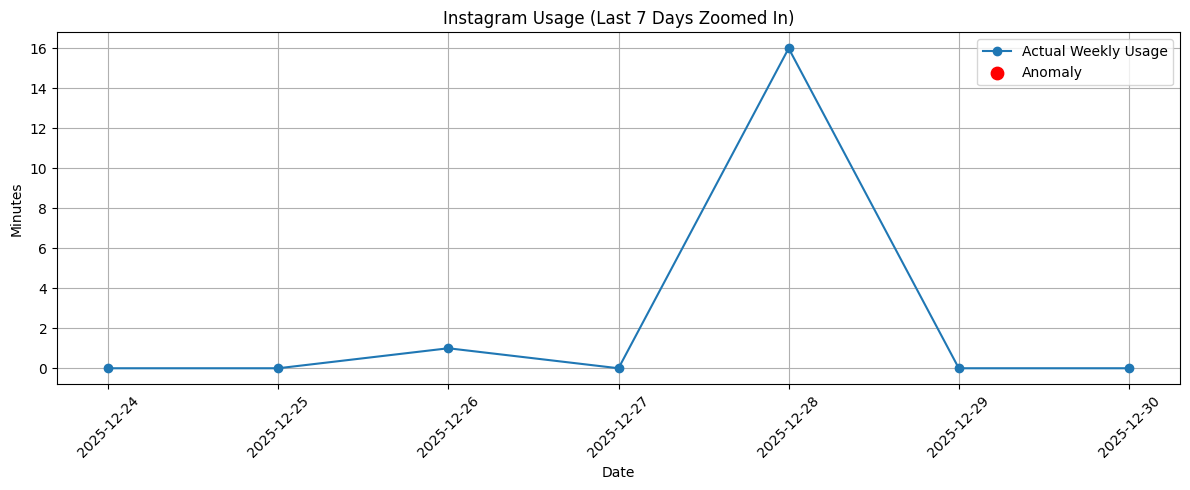

In [8]:
# -----------------------------
# Zoom in on one week of Instagram usage
# -----------------------------
app_to_plot = 'instagram'

if app_to_plot in daily_usage.columns:
    series = daily_usage[app_to_plot]

    # Select the last 7 days (or choose any custom week)
    zoom_start = series.index[-7]
    zoom_end = series.index[-1]

    weekly_series = series.loc[zoom_start:zoom_end]
    weekly_anomalies = anomaly_flags[app_to_plot][-7:]

    plt.figure(figsize=(12,5))

    # Plot actual weekly data
    plt.plot(
        weekly_series.index,
        weekly_series.values,
        marker='o',
        label='Actual Weekly Usage'
    )

    # Highlight anomalies in the selected week
    plt.scatter(
        weekly_series.index[weekly_anomalies],
        weekly_series.values[weekly_anomalies],
        color='red',
        s=80,
        label='Anomaly'
    )

    plt.title(f"{app_to_plot.capitalize()} Usage (Last 7 Days Zoomed In)")
    plt.xlabel("Date")
    plt.ylabel("Minutes")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()